# 匯入套件

In [3]:
import pandas as pd
import pickle
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
%matplotlib inline

# 視覺化分類特徵分布

/mnt/data/yihua/miniconda3/envs/MulEHR/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


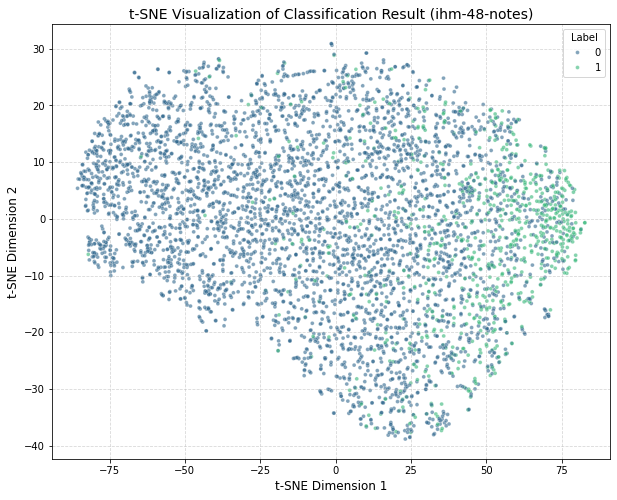

In [5]:
task = 'ihm-48-notes'
filepath = f"/mnt/data/yihua/master/implementations/FuseMoE/src/run/TS_Text/{task}_TS_Text_TS_mTAND_64_Text_mTAND_64_layer1_moe_['laplace']_joint_[16, 5]_top_[4, 4]_batch_0.0004_8_8_128_1_2_512"

with open(os.path.join(filepath, 'sample_result.pkl'), 'rb') as f:
    result = pickle.load(f)

num_sample = result['features'].shape[0]
features = result['features'][:num_sample // 5]
labels = result['labels'][:num_sample // 5]

# 3. 執行 t-SNE
tsne = TSNE(n_components=2, learning_rate='auto', init='pca', random_state=0, n_jobs=-1)
tsne_results = tsne.fit_transform(features)

# 4. 建立 DataFrame 方便繪圖
df = pd.DataFrame(
    {
        "t-SNE 1": tsne_results[:, 0],
        "t-SNE 2": tsne_results[:, 1],
        "Label": labels,
    }
)

# 5. 繪圖
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Label",
    palette="viridis",
    data=df,
    legend="full",
    alpha=0.6,
    s=15,
)

plt.title(f"t-SNE Visualization of Classification Result ({task})", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

output_dir = os.path.join(filepath, "images")
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, f"classification_visualization.png")
plt.savefig(output_path, transparent=False, facecolor='white')
plt.show()
plt.close()